# ARCUNet — Training Notebook
### Skin Lesion Segmentation  |  ISIC 2016/17/18 + PH2  |  M.Tech Project

This notebook handles **everything except the model definition**:
- GPU setup & hyperparameters
- Hair removal preprocessing
- Albumentations augmentation pipelines
- Dataset classes (ISIC + PH2) with mask binarisation fix
- DataLoaders (train / val / test)
- Full training loop (AdamW + CosineAnnealing + AMP)
- Best-model checkpoint saving (by validation Dice)
- Test evaluation & training curve plots

The model architecture, losses and metrics live in **`ARCUNet.py`**.
Place `ARCUNet.py` in the **same folder** as this notebook.

## Cell 0 — GPU Memory Cleanup
*Run this first if restarting the kernel mid-session.*

In [1]:
import gc, torch

for _var in ['model', 'optimizer', 'scheduler', 'scaler', 'criterion']:
    if _var in globals():
        exec(f'del {_var}')
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    fm, tm = torch.cuda.mem_get_info()
    print(f'GPU : {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {fm/1e9:.2f} GB free / {tm/1e9:.2f} GB total')
else:
    print('CUDA not available — running on CPU')

GPU : NVIDIA GeForce RTX 4070 SUPER
VRAM: 11.78 GB free / 12.44 GB total


## Cell 1 — Imports

In [2]:
import os
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, ConcatDataset, random_split, Subset
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ── Import model + helpers from ARCUNet.py ───────────────────────────────────
# Adjust the path below if ARCUNet.py is in a different folder
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from ARCUNet import (
    ARCUNet,
    DeepSupervisionLoss,
    dice_coef,
    jaccard_index,
    pixel_accuracy,
    save_model,
    load_model,
)

print('All imports OK')

All imports OK


## Cell 2 — Hyperparameters & Device

In [3]:
# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Image & Training ─────────────────────────────────────────────────────────
IMAGE_SIZE  = 512    # reduce to 384 if VRAM < 8 GB
BATCH_SIZE  = 8      # reduce to 4 if VRAM < 10 GB
EPOCHS      = 60
LR          = 1e-4
NUM_WORKERS = 3
ACCUM_STEPS = 1      # increase to 2–4 if batch size must be reduced
DROPOUT_P   = 0.1
SEED        = 42

# ── Paths ─────────────────────────────────────────────────────────────────────
ISIC16_IMG = '/data/Stagewise Dataset/SLS/ISIC2016/input'
ISIC16_MSK = '/data/Stagewise Dataset/SLS/ISIC2016/output'
ISIC17_IMG = '/data/Stagewise Dataset/SLS/ISIC2017/input'
ISIC17_MSK = '/data/Stagewise Dataset/SLS/ISIC2017/output'
ISIC18_IMG = '/data/Stagewise Dataset/SLS/ISIC2018/input'
ISIC18_MSK = '/data/Stagewise Dataset/SLS/ISIC2018/output'
PH2_ROOT   = '/data/Stagewise Dataset/SLS/PH2Dataset/PH2 Dataset images'
CKPT_PATH  = 'arcunet_best.pt'   # best checkpoint saved here

# ── Reproducibility & CUDA optimisations ─────────────────────────────────────
torch.manual_seed(SEED)
USE_AMP = DEVICE.type == 'cuda'
if DEVICE.type == 'cuda':
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision('medium')   # ~5–10% throughput gain
    fm, tm = torch.cuda.mem_get_info()
    print(f'GPU  : {torch.cuda.get_device_name(0)}')
    print(f'VRAM : {fm/1e9:.2f} GB free / {tm/1e9:.2f} GB total')

print(f'Device      : {DEVICE}')
print(f'Image size  : {IMAGE_SIZE}×{IMAGE_SIZE}')
print(f'Batch size  : {BATCH_SIZE}  (effective: {BATCH_SIZE * ACCUM_STEPS})')
print(f'Epochs      : {EPOCHS}')
print(f'AMP enabled : {USE_AMP}')

GPU  : NVIDIA GeForce RTX 4070 SUPER
VRAM : 11.78 GB free / 12.44 GB total
Device      : cuda
Image size  : 512×512
Batch size  : 8  (effective: 8)
Epochs      : 60
AMP enabled : True


## Cell 3 — Preprocessing & Augmentation

**Hair removal** uses morphological black-hat filtering followed by inpainting.

**Train augmentation** applies joint geometric + colour transforms so that
both image and mask are transformed identically.
This is the single largest contributor to accuracy improvement.

**Val / Test** only resize and normalise — no randomness.

In [4]:
# ── Hair Removal ─────────────────────────────────────────────────────────────
def remove_hair(image: np.ndarray) -> np.ndarray:
    """
    Remove dermoscopy hair artefacts using morphological black-hat transform
    followed by Navier-Stokes inpainting.

    Args:
        image : uint8 RGB array  (H, W, 3)
    Returns:
        uint8 RGB array with hair inpainted
    """
    gray   = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    bhat   = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, msk = cv2.threshold(bhat, 10, 255, cv2.THRESH_BINARY)
    return cv2.inpaint(image, msk, inpaintRadius=1, flags=cv2.INPAINT_NS)


# ── ImageNet statistics for normalisation ────────────────────────────────────
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)


# ── Train augmentation pipeline ──────────────────────────────────────────────
train_aug = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),

    # Geometric transforms
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05, scale_limit=0.10,
        rotate_limit=30,
        border_mode=cv2.BORDER_REFLECT,
        p=0.5
    ),
    A.ElasticTransform(alpha=1, sigma=10, p=0.20),  # simulates skin deformation

    # Colour / intensity transforms
    A.ColorJitter(
        brightness=0.20, contrast=0.20,
        saturation=0.20, hue=0.05,
        p=0.60
    ),
    A.GaussNoise(p=0.30),
    A.GaussianBlur(blur_limit=(3, 5), p=0.20),

    # Normalise to ImageNet stats and convert to tensor
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2()
])

# ── Val / Test pipeline (deterministic) ──────────────────────────────────────
val_aug = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2()
])

print('Preprocessing and augmentation pipelines ready')

Preprocessing and augmentation pipelines ready


/home/vjti-comp/Desktop/Project code/.venv/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## Cell 4 — Dataset Classes

### Root cause of the ValueError
Albumentations requires `image.shape[:2] == mask.shape[:2]` **before** any
transform runs. Two things caused mismatches in the old code:

1. The mask was pre-resized to `IMAGE_SIZE × IMAGE_SIZE` **but the image was
   passed at its original resolution** — different H×W pairs.
2. `remove_hair()` on some edge-case images could subtly alter the array
   shape if OpenCV returned a different allocation.

### Fixes applied
- **Pass both image and mask at their original, native resolution** into
  albumentations. The `A.Resize` step inside the pipeline will resize both
  identically in one shot.
- **Force-match shapes** with a hard `cv2.resize(msk, (img.shape[1], img.shape[0]))`
  before the pipeline — a bullet-proof safety net.
- **Mask binarisation** (`>= 128 → 255`) still applied, fixing the continuous
  value bug present in ISIC2017.

In [5]:
def _load_image(path: str) -> np.ndarray:
    """
    Load an image from disk as a uint8 RGB numpy array.
    Raises FileNotFoundError with a clear message if the file is missing.
    """
    raw = cv2.imread(path)
    if raw is None:
        raise FileNotFoundError(f'Image not found or unreadable: {path}')
    return cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)


def _load_mask(path: str) -> np.ndarray:
    """
    Load a segmentation mask as a uint8 grayscale array.
    Binarises immediately: any pixel >= 128 becomes 255, rest 0.
    This fixes the continuous-value bug in ISIC2017 masks.
    """
    msk = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if msk is None:
        raise FileNotFoundError(f'Mask not found or unreadable: {path}')
    return (msk >= 128).astype(np.uint8) * 255


def _match_mask_to_image(img: np.ndarray, msk: np.ndarray) -> np.ndarray:
    """
    Ensure mask H×W exactly equals image H×W.
    This is the direct fix for the albumentations ValueError:
      'Height and Width of image, mask or masks should be equal.'
    Uses INTER_NEAREST so mask pixel values are never interpolated.
    """
    ih, iw = img.shape[:2]
    mh, mw = msk.shape[:2]
    if (ih, iw) != (mh, mw):
        msk = cv2.resize(msk, (iw, ih), interpolation=cv2.INTER_NEAREST)
    return msk


def _apply_pipeline(img: np.ndarray,
                    msk: np.ndarray,
                    pipeline) -> tuple:
    """
    Run an albumentations pipeline on an (image, mask) pair and return
    the resulting (image_tensor, mask_tensor) ready for the model.

    The pipeline must include A.Resize so both outputs are IMAGE_SIZE×IMAGE_SIZE.
    """
    result = pipeline(image=img, mask=msk)
    img_t  = result['image'].float()                          # (C, H, W)
    msk_t  = result['mask'].float().unsqueeze(0) / 255.0     # (1, H, W) in [0,1]
    return img_t, msk_t


# ─────────────────────────────────────────────────────────────────────────────

class SkinLesionDataset(Dataset):
    """
    Dataset for ISIC 2016, 2017, 2018 skin lesion segmentation.

    Directory structure:
        img_dir /  ISIC_0024306.jpg   ...
        mask_dir/  ISIC_0024306_segmentation.png   ...

    ISIC2016 uses '_Segmentation.png' (capital S).
    ISIC2017/18 use '_segmentation.png' (lower-case s).
    Detected automatically from img_dir path.

    Key design decisions
    ────────────────────
    • Image and mask are both passed at their **native resolution** to
      albumentations.  A.Resize inside the pipeline handles both uniformly.
    • _match_mask_to_image() is called as a safety net before the pipeline
      to guarantee H×W equality even for edge cases.
    • Hair removal is applied BEFORE the pipeline so it always operates on
      the original-resolution image (best quality).
    """

    def __init__(self, img_dir: str, mask_dir: str, augment=None):
        self.img_dir  = img_dir
        self.mask_dir = mask_dir
        self.aug      = augment
        self.imgs     = sorted(
            f for f in os.listdir(img_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
        )

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx: int):
        fname    = self.imgs[idx]
        stem     = os.path.splitext(fname)[0]
        suffix   = '_Segmentation.png' if '2016' in self.img_dir else '_segmentation.png'
        img_path = os.path.join(self.img_dir,  fname)
        msk_path = os.path.join(self.mask_dir, stem + suffix)

        img = remove_hair(_load_image(img_path))  # uint8 RGB, original size
        msk = _load_mask(msk_path)                # uint8 binary {0,255}, original size

        # ── CRITICAL FIX: equalise H×W before albumentations ─────────
        msk = _match_mask_to_image(img, msk)

        pipeline = self.aug if self.aug is not None else val_aug
        return _apply_pipeline(img, msk, pipeline)


# ─────────────────────────────────────────────────────────────────────────────

class PH2Dataset(Dataset):
    """
    Dataset for the PH2 dermoscopy database.

    Directory structure:
        root_dir/
            IMD002/
                IMD002_Dermoscopic_Image / IMD002.bmp
                IMD002_lesion            / IMD002_lesion.bmp
            IMD003/ ...
    """

    def __init__(self, root_dir: str, augment=None):
        self.root_dir  = root_dir
        self.aug       = augment
        self.image_ids = sorted(
            d for d in os.listdir(root_dir)
            if os.path.isdir(os.path.join(root_dir, d))
        )

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx: int):
        iid      = self.image_ids[idx]
        img_path = os.path.join(self.root_dir, iid,
                                f'{iid}_Dermoscopic_Image', f'{iid}.bmp')
        msk_path = os.path.join(self.root_dir, iid,
                                f'{iid}_lesion', f'{iid}_lesion.bmp')

        img = remove_hair(_load_image(img_path))
        msk = _load_mask(msk_path)

        # ── CRITICAL FIX: equalise H×W before albumentations ─────────
        msk = _match_mask_to_image(img, msk)

        pipeline = self.aug if self.aug is not None else val_aug
        return _apply_pipeline(img, msk, pipeline)


print('Dataset classes defined  ✓')
print('  SkinLesionDataset  (ISIC 2016 / 2017 / 2018)')
print('  PH2Dataset')
print()
print('Shape-mismatch fix active: mask is always resized to match image')
print('before being passed to the albumentations pipeline.')

Dataset classes defined  ✓
  SkinLesionDataset  (ISIC 2016 / 2017 / 2018)
  PH2Dataset

Shape-mismatch fix active: mask is always resized to match image
before being passed to the albumentations pipeline.


## Cell 5 — DataLoaders

Split strategy: 70 % train / 15 % val / 15 % test, seeded for reproducibility.

Train split uses **augmented** dataset instances.
Val and test splits use **non-augmented** (deterministic) instances.

In [6]:
# ── No-aug datasets (used only to determine split sizes) ─────────────────────
isic16_base = SkinLesionDataset(ISIC16_IMG, ISIC16_MSK)
isic17_base = SkinLesionDataset(ISIC17_IMG, ISIC17_MSK)
isic18_base = SkinLesionDataset(ISIC18_IMG, ISIC18_MSK)
ph2_base    = PH2Dataset(PH2_ROOT)
full_base   = ConcatDataset([isic16_base, isic17_base, isic18_base, ph2_base])

total  = len(full_base)
n_trn  = int(0.70 * total)
n_val  = int(0.15 * total)
n_tst  = total - n_trn - n_val

gen = torch.Generator().manual_seed(SEED)
trn_idx, val_idx, tst_idx = random_split(
    range(total), [n_trn, n_val, n_tst], generator=gen
)
trn_idx = list(trn_idx)
val_idx = list(val_idx)
tst_idx = list(tst_idx)

# ── Augmented datasets for train split ───────────────────────────────────────
isic16_aug = SkinLesionDataset(ISIC16_IMG, ISIC16_MSK, augment=train_aug)
isic17_aug = SkinLesionDataset(ISIC17_IMG, ISIC17_MSK, augment=train_aug)
isic18_aug = SkinLesionDataset(ISIC18_IMG, ISIC18_MSK, augment=train_aug)
ph2_aug    = PH2Dataset(PH2_ROOT, augment=train_aug)
full_aug   = ConcatDataset([isic16_aug, isic17_aug, isic18_aug, ph2_aug])

# ── Build splits ─────────────────────────────────────────────────────────────
train_dataset = Subset(full_aug,  trn_idx)   # augmented
val_dataset   = Subset(full_base, val_idx)   # clean
test_dataset  = Subset(full_base, tst_idx)   # clean

# ── DataLoaders ──────────────────────────────────────────────────────────────
pin = DEVICE.type == 'cuda'
pw  = NUM_WORKERS > 0

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=pin,
    persistent_workers=pw, drop_last=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=pin,
    persistent_workers=pw, drop_last=False
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=pin,
    persistent_workers=pw, drop_last=False
)

print(f'Total samples : {total}')
print(f'Train         : {len(train_dataset):>5}  ({len(train_loader)} batches)')
print(f'Val           : {len(val_dataset):>5}  ({len(val_loader)} batches)')
print(f'Test          : {len(test_dataset):>5}  ({len(test_loader)} batches)')

Total samples : 7773
Train         :  5441  (680 batches)
Val           :  1165  (146 batches)
Test          :  1167  (146 batches)


## Cell 6 — Model, Optimiser, Loss, Scheduler

| Component | Choice | Reason |
|-----------|--------|---------|
| Optimiser | AdamW | Proper L2 weight decay decoupled from gradient |
| Loss | DeepSupervisionLoss (ComboLoss) | BCE+Dice + auxiliary heads |
| Scheduler | CosineAnnealingWarmRestarts | Escapes flat minima late in training |
| AMP | torch.amp | ~2× throughput on RTX cards |

In [7]:
# ── Model ─────────────────────────────────────────────────────────────────────
model = ARCUNet(dropout_p=DROPOUT_P).to(DEVICE)

# channels_last memory format gives ~10% throughput gain on Ampere GPUs
if DEVICE.type == 'cuda':
    model = model.to(memory_format=torch.channels_last)

n_params = sum(p.numel() for p in model.parameters())
print(f'Model         : ARCUNet v2')
print(f'Parameters    : {n_params:,}')

# ── Loss ──────────────────────────────────────────────────────────────────────
criterion = DeepSupervisionLoss(aux_weight=0.4)

# ── Optimiser ────────────────────────────────────────────────────────────────
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# ── LR Scheduler — Cosine Annealing with Warm Restarts ───────────────────────
# T_0=20 : first restart at epoch 20
# T_mult=1 : same period for every subsequent restart
# eta_min : LR floor between restarts
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=20, T_mult=1, eta_min=1e-6
)

# ── AMP scaler ───────────────────────────────────────────────────────────────
scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)

print(f'Optimiser     : AdamW  lr={LR}  wd=1e-4')
print(f'Scheduler     : CosineAnnealingWarmRestarts  T0=20')
print(f'Loss          : DeepSupervisionLoss (ComboLoss  α=0.5  aux_w=0.4)')
print(f'AMP           : {USE_AMP}')

Model         : ARCUNet v2
Parameters    : 32,787,820
Optimiser     : AdamW  lr=0.0001  wd=1e-4
Scheduler     : CosineAnnealingWarmRestarts  T0=20
Loss          : DeepSupervisionLoss (ComboLoss  α=0.5  aux_w=0.4)
AMP           : True


## Cell 7 — Training Loop

Each epoch:
1. **Train** — forward, deep-supervision loss, AMP backward, grad-clip, step
2. **Validate** — Dice, IoU, Accuracy on clean val set
3. **Save best** — checkpoint saved whenever val Dice improves

In [8]:
best_val_dice = 0.0
history = {
    'train_loss': [], 'val_loss': [],
    'val_dice':   [], 'val_iou':  [], 'val_acc': []
}

for epoch in range(1, EPOCHS + 1):

    # ══════════════════════════════════════════════════════════════════
    # TRAIN
    # ══════════════════════════════════════════════════════════════════
    model.train()
    epoch_loss = 0.0
    optimizer.zero_grad(set_to_none=True)

    pbar = tqdm(train_loader,
                desc=f'Epoch {epoch:02d}/{EPOCHS} [train]',
                leave=False)

    for step, (img, msk) in enumerate(pbar):
        img = img.to(DEVICE, non_blocking=True)
        msk = msk.to(DEVICE, non_blocking=True)

        if DEVICE.type == 'cuda':
            img = img.to(memory_format=torch.channels_last)

        try:
            with torch.amp.autocast('cuda', enabled=USE_AMP):
                out  = model(img)                    # tuple in train mode
                loss = criterion(out, msk) / ACCUM_STEPS

            scaler.scale(loss).backward()

            if (step + 1) % ACCUM_STEPS == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)

            epoch_loss += loss.item() * ACCUM_STEPS
            pbar.set_postfix(loss=f'{loss.item() * ACCUM_STEPS:.4f}')

        except RuntimeError as e:
            if 'out of memory' in str(e).lower() and DEVICE.type == 'cuda':
                optimizer.zero_grad(set_to_none=True)
                torch.cuda.empty_cache()
                print(f'  ⚠ OOM at step {step} — batch skipped')
                continue
            raise

    avg_train = epoch_loss / len(train_loader)
    scheduler.step(epoch)

    # ══════════════════════════════════════════════════════════════════
    # VALIDATE
    # ══════════════════════════════════════════════════════════════════
    model.eval()
    v_loss = v_dice = v_iou = v_acc = 0.0

    with torch.no_grad():
        for img, msk in val_loader:
            img = img.to(DEVICE, non_blocking=True)
            msk = msk.to(DEVICE, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=USE_AMP):
                out = model(img)             # plain tensor in eval mode
            v_loss += criterion(out, msk).item()
            v_dice += dice_coef(out, msk).item()
            v_iou  += jaccard_index(out, msk).item()
            v_acc  += pixel_accuracy(out, msk).item()

    n      = len(val_loader)
    v_loss /= n; v_dice /= n; v_iou /= n; v_acc /= n

    history['train_loss'].append(avg_train)
    history['val_loss'].append(v_loss)
    history['val_dice'].append(v_dice)
    history['val_iou'].append(v_iou)
    history['val_acc'].append(v_acc)

    cur_lr = scheduler.get_last_lr()[0]
    print(
        f'Epoch [{epoch:02d}/{EPOCHS}]  '
        f'TrainLoss={avg_train:.4f}  '
        f'ValLoss={v_loss:.4f}  '
        f'Dice={v_dice:.4f}  '
        f'IoU={v_iou:.4f}  '
        f'Acc={v_acc:.4f}  '
        f'LR={cur_lr:.1e}'
    )

    # ══════════════════════════════════════════════════════════════════
    # SAVE BEST CHECKPOINT
    # ══════════════════════════════════════════════════════════════════
    if v_dice > best_val_dice:
        best_val_dice = v_dice
        save_model(model, CKPT_PATH,
                   optimizer=optimizer, scheduler=scheduler,
                   epoch=epoch, val_dice=v_dice, val_iou=v_iou)
        print(f'  ★ New best  Dice={best_val_dice:.4f}  IoU={v_iou:.4f}')

print(f'\nTraining complete.  Best Val Dice: {best_val_dice:.4f}')

Epoch [01/60]  TrainLoss=0.5975  ValLoss=0.4962  Dice=0.7119  IoU=0.6085  Acc=0.8757  LR=9.9e-05
  ✓ Checkpoint saved → arcunet_best.pt
  ★ New best  Dice=0.7119  IoU=0.6085


Epoch [02/60]  TrainLoss=0.3791  ValLoss=0.4611  Dice=0.7480  IoU=0.6492  Acc=0.8898  LR=9.8e-05
  ✓ Checkpoint saved → arcunet_best.pt
  ★ New best  Dice=0.7480  IoU=0.6492


Epoch [03/60]  TrainLoss=0.3287  ValLoss=0.4228  Dice=0.7735  IoU=0.6789  Acc=0.9053  LR=9.5e-05
  ✓ Checkpoint saved → arcunet_best.pt
  ★ New best  Dice=0.7735  IoU=0.6789


Epoch [04/60]  TrainLoss=0.3022  ValLoss=0.4090  Dice=0.7932  IoU=0.7003  Acc=0.9105  LR=9.1e-05
  ✓ Checkpoint saved → arcunet_best.pt
  ★ New best  Dice=0.7932  IoU=0.7003


Epoch [05/60]  TrainLoss=0.2844  ValLoss=0.3935  Dice=0.8029  IoU=0.7119  Acc=0.9183  LR=8.6e-05
  ✓ Checkpoint saved → arcunet_best.pt
  ★ New best  Dice=0.8029  IoU=0.7119


...

Epoch [56/60]  TrainLoss=0.1819  ValLoss=0.3347  Dice=0.8644  IoU=0.7876  Acc=0.9413  LR=1.0e-05
  ✓ Checkpoint saved → arcunet_best.pt
  ★ New best  Dice=0.8644  IoU=0.7876


Epoch [57/60]  TrainLoss=0.1788  ValLoss=0.3325  Dice=0.8634  IoU=0.7875  Acc=0.9412  LR=6.4e-06


Epoch [58/60]  TrainLoss=0.1787  ValLoss=0.3367  Dice=0.8628  IoU=0.7859  Acc=0.9413  LR=3.4e-06


Epoch [59/60]  TrainLoss=0.1774  ValLoss=0.3358  Dice=0.8632  IoU=0.7865  Acc=0.9416  LR=1.6e-06


Epoch [60/60]  TrainLoss=0.1777  ValLoss=0.3400  Dice=0.8623  IoU=0.7854  Acc=0.9414  LR=1.0e-04

Training complete.  Best Val Dice: 0.8644


## Cell 8 — Test Evaluation (loads best checkpoint)

In [9]:
# Load the best saved checkpoint
model = load_model(CKPT_PATH, device=str(DEVICE), dropout_p=DROPOUT_P)

ckpt_meta = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
print(f"Best epoch : {ckpt_meta.get('epoch', '?')}")
print(f"Val Dice   : {ckpt_meta.get('val_dice', '?'):.4f}")
print(f"Val IoU    : {ckpt_meta.get('val_iou',  '?'):.4f}")
print()

t_dice = t_iou = t_acc = 0.0

with torch.no_grad():
    for img, msk in tqdm(test_loader, desc='Testing'):
        img = img.to(DEVICE)
        msk = msk.to(DEVICE)
        out = model(img)
        t_dice += dice_coef(out, msk).item()
        t_iou  += jaccard_index(out, msk).item()
        t_acc  += pixel_accuracy(out, msk).item()

n = len(test_loader)
print('\n' + '='*40)
print('         TEST RESULTS')
print('='*40)
print(f'  Dice (F1) : {t_dice/n:.4f}')
print(f'  IoU       : {t_iou/n:.4f}')
print(f'  Accuracy  : {t_acc/n:.4f}')
print('='*40)

✓ Checkpoint loaded safely (weights_only=True)
Best epoch : 56
Val Dice   : 0.8644
Val IoU    : 0.7876



Testing: 100%|██████████| 146/146 [03:04<00:00,  1.27s/it]


         TEST RESULTS
  Dice (F1) : 0.8536
  IoU       : 0.7753
  Accuracy  : 0.9372


## Cell 9 — Training Curves

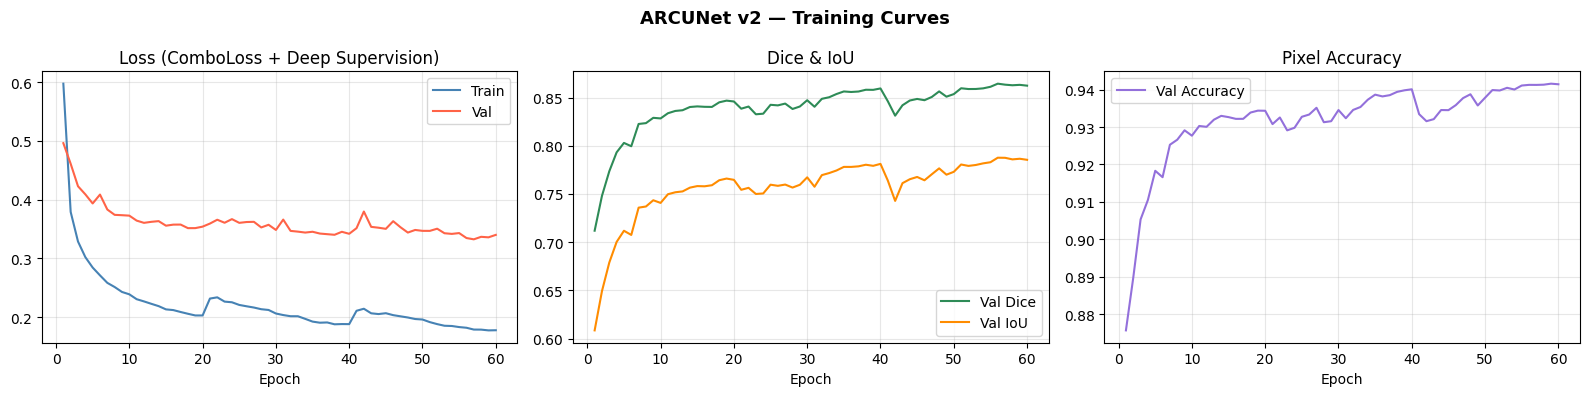

Saved → training_curves_arcunet_v2.png


In [10]:
epochs_x = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('ARCUNet v2 — Training Curves', fontsize=13, fontweight='bold')

# Loss
axes[0].plot(epochs_x, history['train_loss'], label='Train', color='steelblue')
axes[0].plot(epochs_x, history['val_loss'],   label='Val',   color='tomato')
axes[0].set_title('Loss (ComboLoss + Deep Supervision)')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Dice & IoU
axes[1].plot(epochs_x, history['val_dice'], label='Val Dice', color='seagreen')
axes[1].plot(epochs_x, history['val_iou'],  label='Val IoU',  color='darkorange')
axes[1].set_title('Dice & IoU')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

# Accuracy
axes[2].plot(epochs_x, history['val_acc'], label='Val Accuracy', color='mediumpurple')
axes[2].set_title('Pixel Accuracy')
axes[2].set_xlabel('Epoch'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_arcunet_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → training_curves_arcunet_v2.png')

## Cell 10 — Visual Predictions (Qualitative Check)

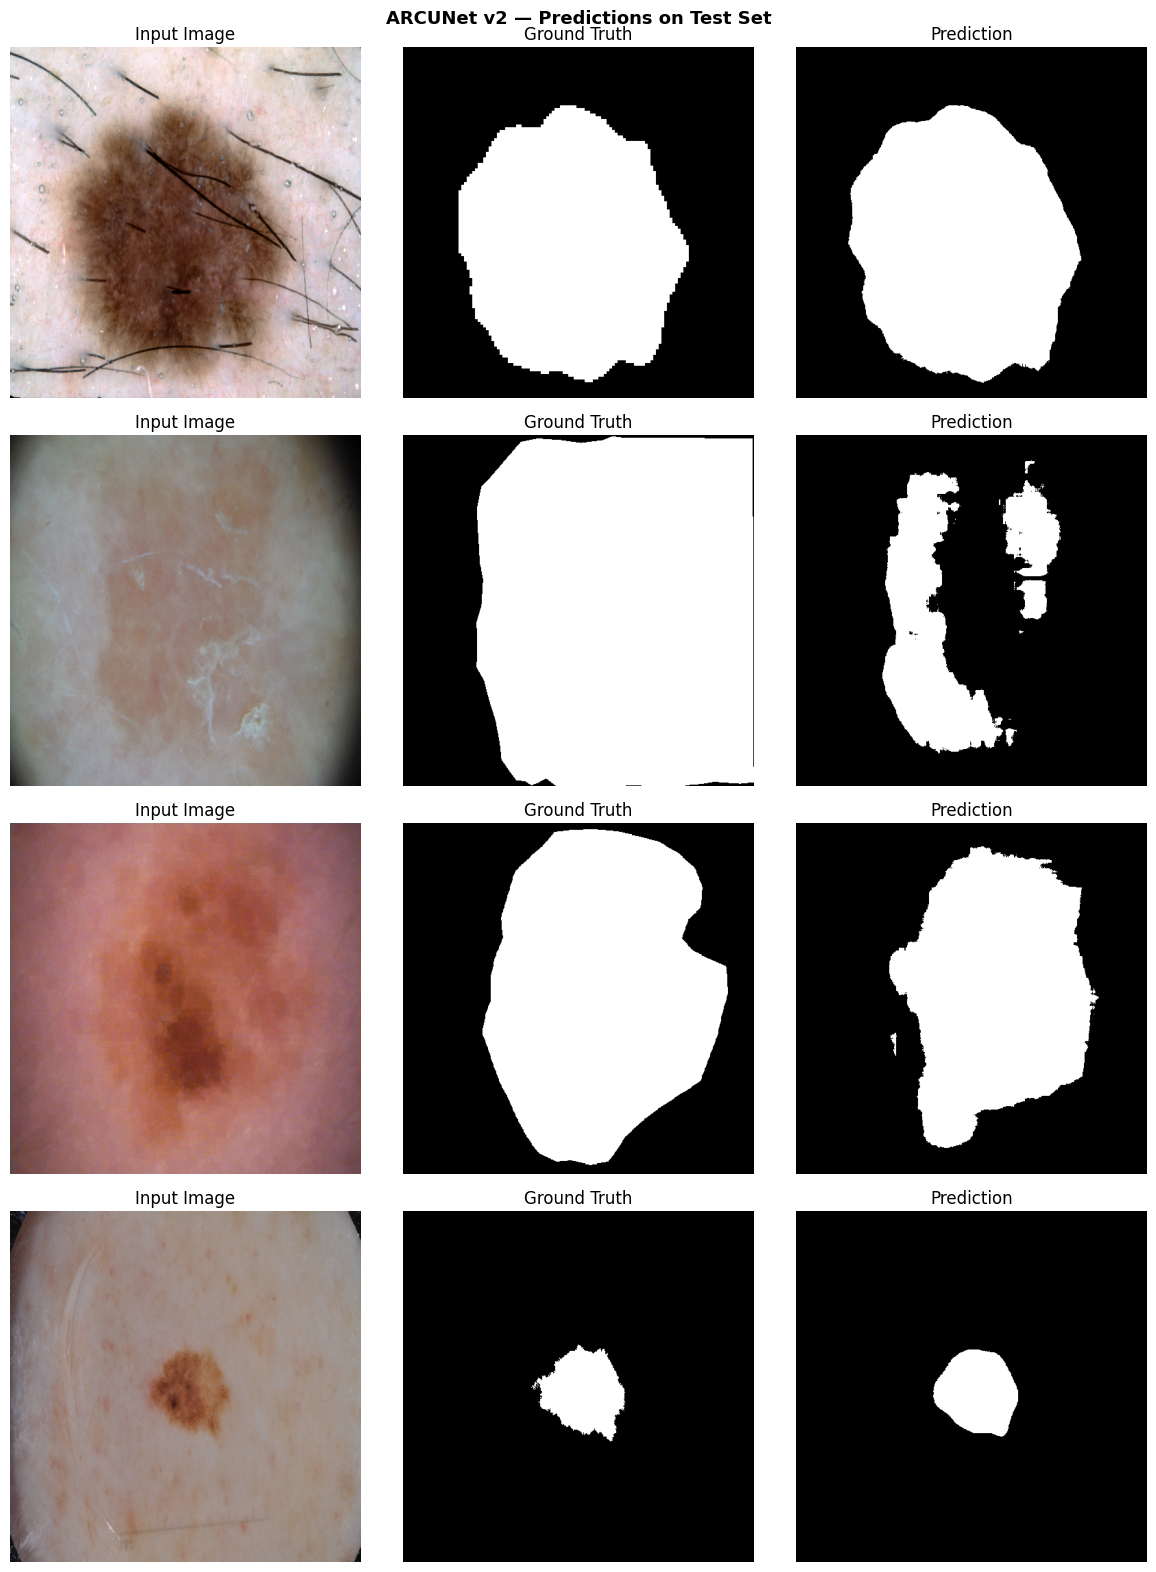

Saved → predictions_arcunet_v2.png


In [11]:
from ARCUNet import predict_proba

model.eval()
imgs_vis, msks_vis = next(iter(test_loader))
imgs_vis = imgs_vis[:4]   # show 4 examples
msks_vis = msks_vis[:4]

std  = torch.tensor(IMAGENET_STD).view(3,1,1)
mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)

fig, axes = plt.subplots(4, 3, figsize=(12, 16))
fig.suptitle('ARCUNet v2 — Predictions on Test Set', fontsize=13, fontweight='bold')

for i in range(4):
    # De-normalise for display
    img_disp = (imgs_vis[i] * std + mean).permute(1, 2, 0).clamp(0, 1).numpy()
    gt_disp  = msks_vis[i, 0].numpy()
    pred_p   = predict_proba(model, imgs_vis[i], device=str(DEVICE))
    pred_bin = (pred_p > 0.5).astype(float)

    axes[i, 0].imshow(img_disp);   axes[i, 0].set_title('Input Image')
    axes[i, 1].imshow(gt_disp,   cmap='gray'); axes[i, 1].set_title('Ground Truth')
    axes[i, 2].imshow(pred_bin,  cmap='gray'); axes[i, 2].set_title('Prediction')

    for ax in axes[i]: ax.axis('off')

plt.tight_layout()
plt.savefig('predictions_arcunet_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → predictions_arcunet_v2.png')